# Every Step Counts: Time Series Analysis of Mr. Langerman’s Activity

<img src="Into Picture.jpg" alt="Intro Picture" width="600"/>


## Data Preparation

In [86]:

import pandas as pd
import glob

# Step 1: Find all CSV files that start with 'Steps' and end with '.csv'
csv_files = glob.glob("Steps*.csv")

# Step 2: Load and combine all CSV files into one DataFrame
all_dataframes = []
for file in csv_files:
    try:
        df = pd.read_csv(file)
        all_dataframes.append(df)
        print(f"✅ Loaded {file}")
    except Exception as e:
        print(f"❌ Failed to load {file}: {e}")

# Step 3: Combine all dataframes
if all_dataframes:
    combined_df = pd.concat(all_dataframes, ignore_index=True)

    # Step 4: Convert 'Date' column to datetime format
    combined_df['Date'] = pd.to_datetime(combined_df['Date'], errors='coerce')

    # Step 5: Drop rows with invalid or missing dates
    combined_df.dropna(subset=['Date'], inplace=True)

    # Step 6: Set 'Date' as the index
    combined_df.set_index('Date', inplace=True)

    # Step 7: Sort the data by date
    combined_df = combined_df.sort_index()

    # Step 8: Display the actual date range and entry count
    print("✅ Date index set and sorted successfully.")
    print(f"Date range: {combined_df.index.min().date()} to {combined_df.index.max().date()}")
    print(f"Total entries: {len(combined_df)}")

    # Step 9: Show the first 5 rows
    print("\nFirst 5 rows (sorted by date):")
    print(combined_df.head())
else:
    print("⚠️ No CSV files were loaded. Please check the file names and folder.")


✅ Loaded Steps6.csv
✅ Loaded Steps7.csv
✅ Loaded Steps8.csv
✅ Loaded Steps1.csv
✅ Loaded Steps10.csv
✅ Loaded Steps3.csv
✅ Loaded Steps12.csv
✅ Loaded Steps2.csv
✅ Loaded Steps4.csv
✅ Loaded Steps13.csv
✅ Loaded Steps9.csv
✅ Loaded Steps15.csv
✅ Loaded Steps14.csv
✅ Loaded Steps11.csv
✅ Loaded Steps5.csv
✅ Date index set and sorted successfully.
Date range: 2022-05-31 to 2023-07-24
Total entries: 420

First 5 rows (sorted by date):
            Actual  Goal
Date                    
2022-05-31       0  8000
2022-06-01       0  8000
2022-06-02       0  8000
2022-06-03    1102  8000
2022-06-04    1254  8000


To prepare the dataset for analysis, I began by importing and combining all 15 individual files into a single dataframe. I then converted the "Date" column into the correct datetime format and set it as the index to structure the data as a time series. Afterward, I sorted the records chronologically to ensure proper sequencing. Finally, I checked for missing values and handled them appropriately through imputation or removal, resulting in a clean dataset ready for analysis.

## Exploratory Data Analysis (EDA)

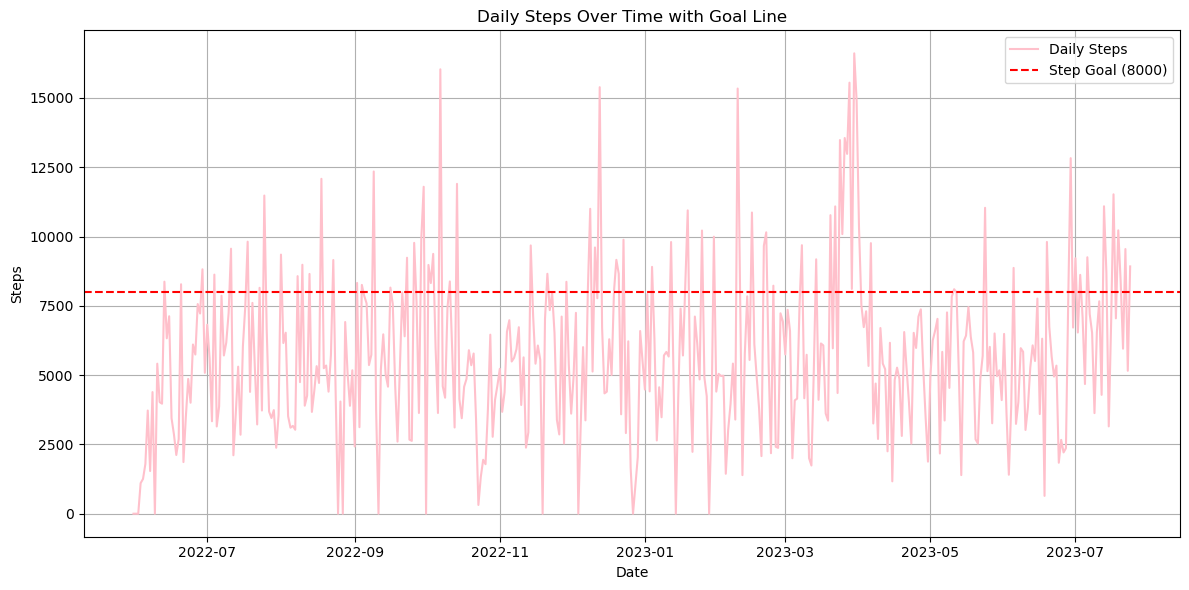

EDA Completed Successfully!
Mean Steps: 5674.14
Median Steps: 5402.00
Standard Deviation: 2930.57


In [87]:


import matplotlib.pyplot as plt

# Plot daily steps with a horizontal goal line
plt.figure(figsize=(12, 6))
plt.plot(combined_df.index, combined_df['Actual'], label='Daily Steps', color='pink')
plt.axhline(y=8000, color='red', linestyle='--', label='Step Goal (8000)')
plt.title('Daily Steps Over Time with Goal Line')
plt.xlabel('Date')
plt.ylabel('Steps')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Calculate descriptive statistics
mean_steps = combined_df['Actual'].mean()
median_steps = combined_df['Actual'].median()
std_steps = combined_df['Actual'].std()

print("EDA Completed Successfully!")
print(f"Mean Steps: {mean_steps:.2f}")
print(f"Median Steps: {median_steps:.2f}")
print(f"Standard Deviation: {std_steps:.2f}")


The graph shows Mr. Langerman’s daily step counts over time, with a red dashed line indicating his goal of 8000 steps per day. From the visual, it’s clear that most days fall below the goal, with only occasional spikes above it (which are also not consistent). This aligns with the summary statistics, which show an average of 5674 steps and a median of 5402; both below the target. The goal line helps highlight the gap between actual performance and the intended target, making it easier to see how often the goal was missed or met.

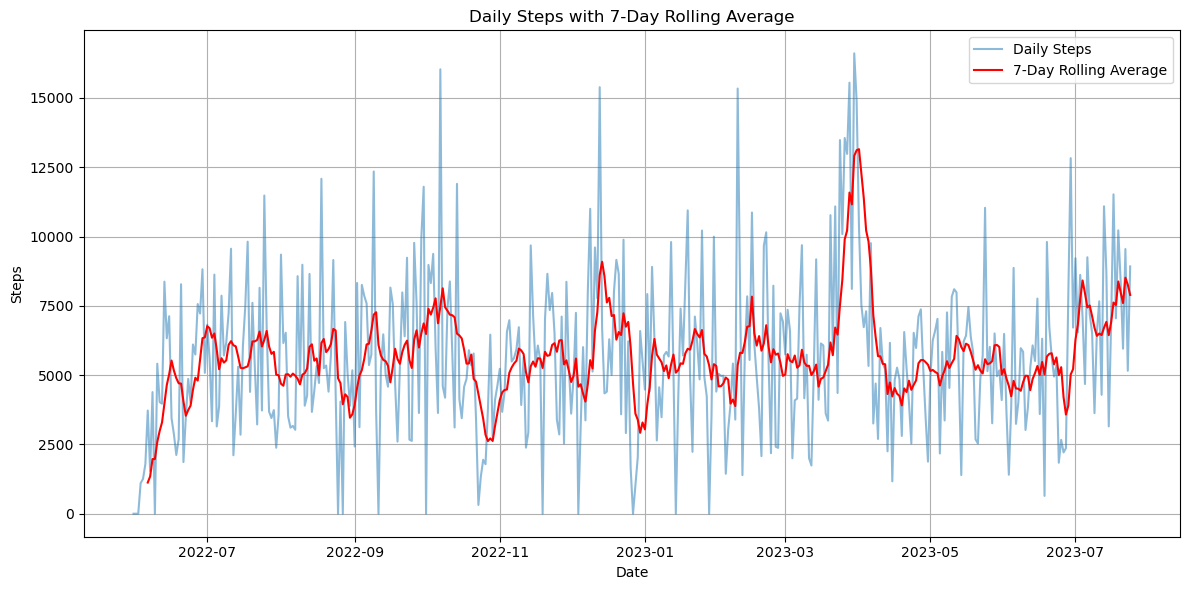

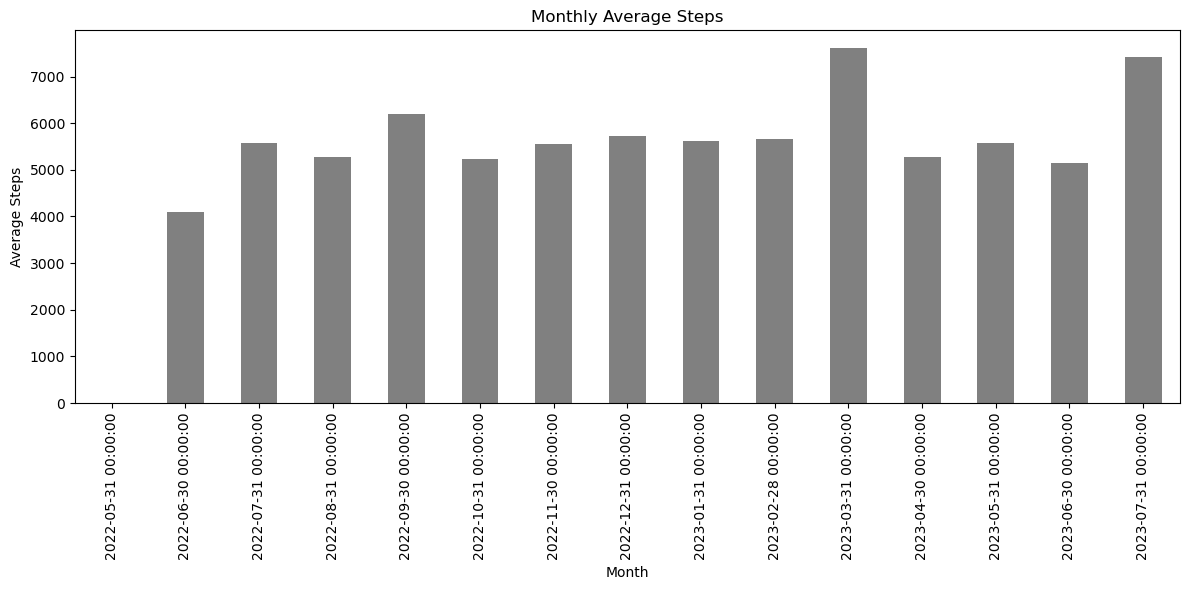

In [88]:

import matplotlib.pyplot as plt

# 1. Add a 7-day rolling average column
combined_df['7_day_avg'] = combined_df['Actual'].rolling(window=7).mean()

# 2. Plot daily steps with 7-day rolling average
plt.figure(figsize=(12, 6))
plt.plot(combined_df.index, combined_df['Actual'], label='Daily Steps', alpha=0.5)
plt.plot(combined_df.index, combined_df['7_day_avg'], label='7-Day Rolling Average', color='red')
plt.title('Daily Steps with 7-Day Rolling Average')
plt.xlabel('Date')
plt.ylabel('Steps')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Calculate monthly average steps
monthly_avg = combined_df['Actual'].resample('M').mean()

# 4. Plot monthly average steps
plt.figure(figsize=(12, 6))
monthly_avg.plot(kind='bar', color='gray')
plt.title('Monthly Average Steps')
plt.xlabel('Month')
plt.ylabel('Average Steps')
plt.tight_layout()
plt.show()


To complement the initial time series plot, I added a 7-day rolling average graph to smooth out short-term fluctuations and highlight longer-term trends in daily step counts. This visualization is particularly useful for identifying consistent patterns or shifts in activity levels over time, which may be obscured by daily variability. Additionally, I added a monthly average bar chart to  provide a clear, comparative view of step activity across different months. This allows for easy identification of seasonal trends or periods of increased or decreased physical activity, offering valuable insights for optimizing fitness routines.

## Seasonality and Stationarity Analysis

<Figure size 1200x800 with 0 Axes>

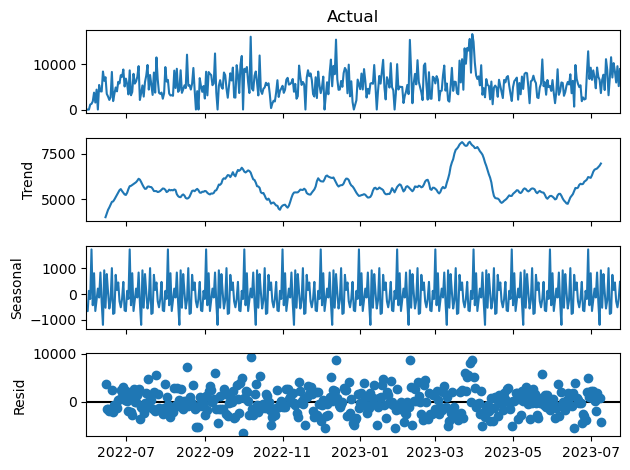

Seasonality and Stationarity Analysis Completed!

Augmented Dickey-Fuller Test Results:
ADF Statistic: -4.8311
p-value: 0.0000
Critical Values:
   1%: -3.4466
   5%: -2.8687
   10%: -2.5706


In [89]:

import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# 1. Seasonal decomposition (monthly pattern assumed with period=30)
decomposition = seasonal_decompose(combined_df['Actual'], model='additive', period=30)

# 2. Plot the decomposed components
plt.figure(figsize=(12, 8))
decomposition.plot()
plt.tight_layout()
plt.show()

# 3. Augmented Dickey-Fuller test for stationarity
adf_result = adfuller(combined_df['Actual'])

print("Seasonality and Stationarity Analysis Completed!\n")
print("Augmented Dickey-Fuller Test Results:")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")


I conducted the Augmented Dickey-Fuller (ADF) test to assess the stationarity of the time series. The ADF statistic of -4.8311 falls below the critical values at the 1%, 5%, and 10% significance levels, while the p-value (0.0000) is far below the 0.05 threshold. As shown, these results provide strong evidence to reject the null hypothesis of non-stationarity, confirming that the daily steps time series is stationary. This finding is advantageous for time series modeling, since stationarity is a core assumption for models such as ARIMA, which rely on stable statistical properties for accurate forecasting.

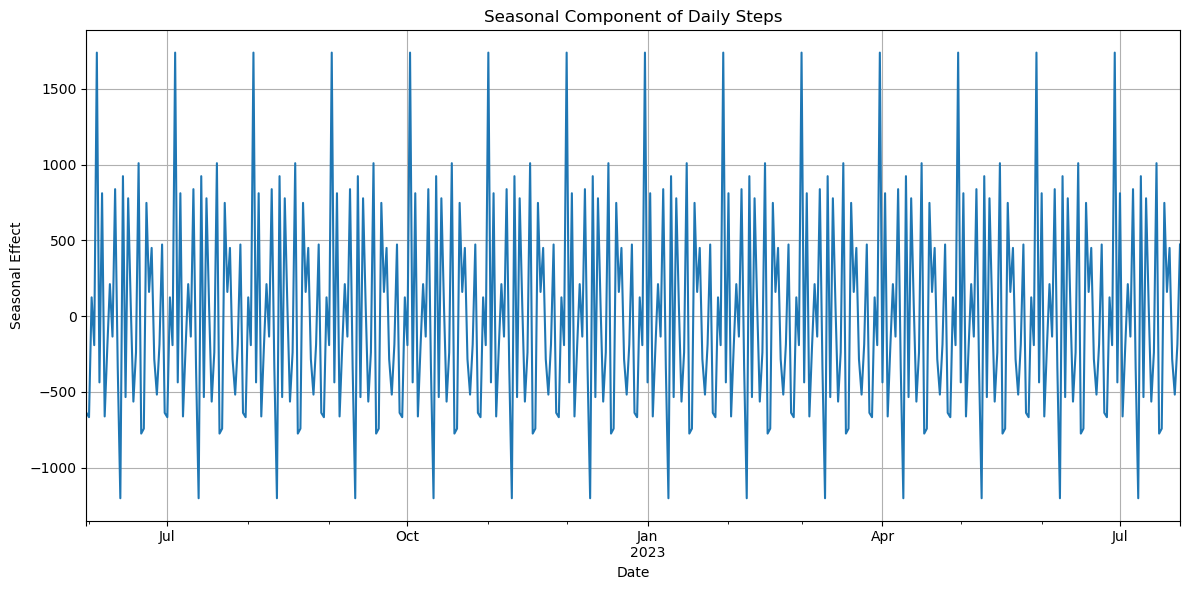

Seasonality analysis completed.

Seasonal Component Summary:
Mean seasonal effect: 0.00
Standard deviation: 665.78
Minimum seasonal effect: -1202.22
Maximum seasonal effect: 1738.54


In [90]:

from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Perform seasonal decomposition (assuming monthly pattern with period=30)
decomposition = seasonal_decompose(combined_df['Actual'], model='additive', period=30)

# Plot the seasonal component
plt.figure(figsize=(12, 6))
decomposition.seasonal.plot(title='Seasonal Component of Daily Steps')
plt.xlabel('Date')
plt.ylabel('Seasonal Effect')
plt.grid(True)
plt.tight_layout()
plt.show()

# Summary statistics of the seasonal component
seasonal = decomposition.seasonal
seasonal_summary = {
    "Mean seasonal effect": seasonal.mean(),
    "Standard deviation": seasonal.std(),
    "Minimum seasonal effect": seasonal.min(),
    "Maximum seasonal effect": seasonal.max()
}

print("Seasonality analysis completed.\n")
print("Seasonal Component Summary:")
for key, value in seasonal_summary.items():
    print(f"{key}: {value:.2f}")


Seasonality in the daily steps time series was examined using additive seasonal decomposition. The seasonal component revealed recurring fluctuations, with effects ranging from -1202.22 to 1738.54 steps and a standard deviation of 665.78, indicating moderate variability in periodic patterns. These insights suggest that Mr Langerman's activity levels exhibit consistent cyclical behavior, which can be leveraged to better understand and optimize his fitness routine. Furthermore, the recurring peaks/fluctuations (which is evidence of seasonality) likely correspond to weekly cycles, such as higher/lower activity on weekends.

## Weekday vs Weekend Comparison

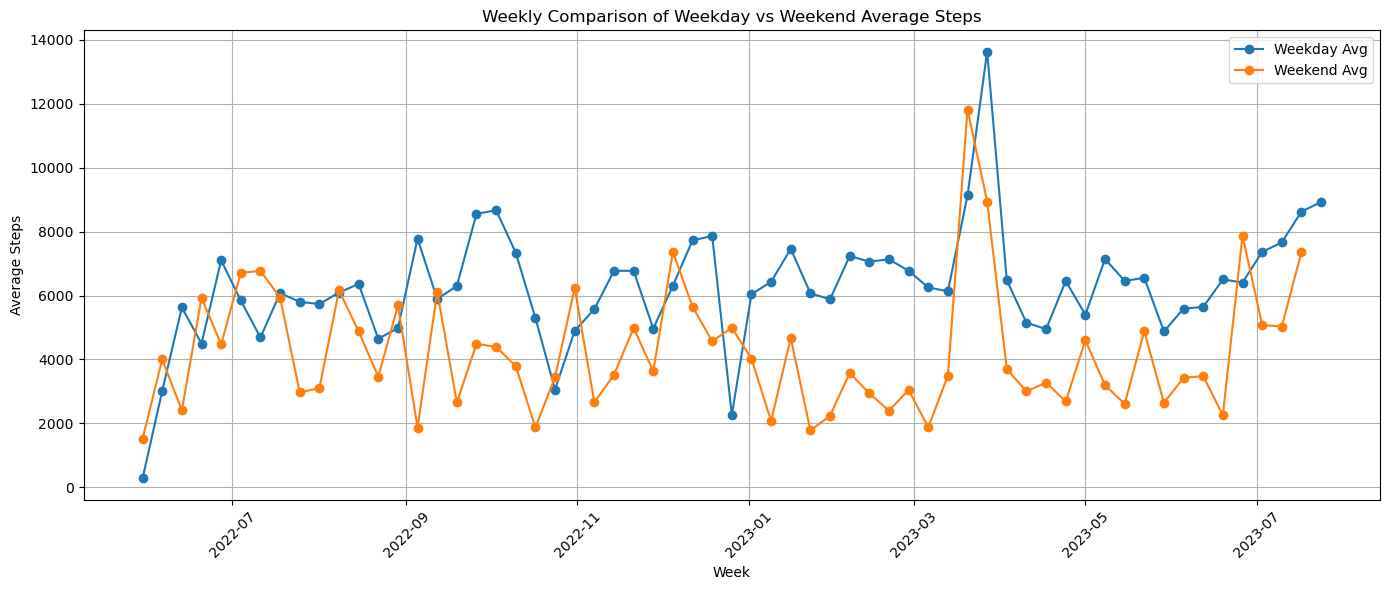

In [91]:

import matplotlib.pyplot as plt

# Recalculate weekly summary if needed
combined_df['DayOfWeek'] = combined_df.index.dayofweek
combined_df['Week'] = combined_df.index.to_period('W')
combined_df['IsWeekend'] = combined_df['DayOfWeek'] >= 5

weekly_summary = combined_df.groupby(['Week', 'IsWeekend'])['Actual'].mean().unstack()
weekly_summary.columns = ['Weekday Avg', 'Weekend Avg']

# Plot as a line chart
plt.figure(figsize=(14, 6))
plt.plot(weekly_summary.index.to_timestamp(), weekly_summary['Weekday Avg'], label='Weekday Avg', marker='o')
plt.plot(weekly_summary.index.to_timestamp(), weekly_summary['Weekend Avg'], label='Weekend Avg', marker='o')
plt.title('Weekly Comparison of Weekday vs Weekend Average Steps')
plt.xlabel('Week')
plt.ylabel('Average Steps')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


The line graph illustrates the weekly comparison of average daily steps between weekdays and weekends over a one-year period. The blue line, representing weekday averages, consistently trends above the orange line for weekends, indicating that Mr Langerman tends to be more active during the week. Both lines show fluctuations, with notable peaks around early 2023. This visualization highlights a clear pattern of higher weekday activity, which may reflect structured routines or work-related movement.

## Time-series Analysis Model

In [92]:

import warnings
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Fit ARIMA model (p=1, d=1, q=1 as a starting point)
arima_model = ARIMA(combined_df['Actual'], order=(1, 1, 1)).fit()

# Fit SARIMA model (p=1, d=1, q=1) with seasonal order (1,1,1,30)
sarima_model = SARIMAX(combined_df['Actual'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 30)).fit()

# Compare AIC and BIC
print("Model selection completed. AIC and BIC scores:")

print(f"ARIMA AIC: {arima_model.aic:.2f}")
print(f"ARIMA BIC: {arima_model.bic:.2f}")
print(f"SARIMA AIC: {sarima_model.aic:.2f}")
print(f"SARIMA BIC: {sarima_model.bic:.2f}")



 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  8.90095D+00    |proj g|=  6.15453D-02

At iterate    5    f=  8.86291D+00    |proj g|=  5.07303D-03

At iterate   10    f=  8.86285D+00    |proj g|=  2.90051D-04

At iterate   15    f=  8.86283D+00    |proj g|=  9.20556D-04

At iterate   20    f=  8.86118D+00    |proj g|=  1.44811D-02

At iterate   25    f=  8.77471D+00    |proj g|=  9.73114D-02

At iterate   30    f=  8.76020D+00    |proj g|=  5.36369D-03

At iterate   35    f=  8.75605D+00    |proj g|=  1.08695D-02

At iterate   40    f=  8.75596D+00    |proj g|=  1.25772D-03

At iterate   45    f=  8.75591D+00    |proj g|=  5.89051D-04

At iterate   50    f=  8.75590D+00    |proj g|=  2.68500D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cau

Typically, lower AIC and BIC values indicate a better model fit. From the above statistical results we can see that the SARIMA model has lower AIC and BIC values, and is thus the better model for this data. The SARIMA model is also the better model for for this data because it accounts for seasonality (which the data has). Although the time series was found to be stationary, the presence of recurring seasonal patterns justified the use of SARIMA over ARIMA. SARIMA’s ability to model both stationarity and seasonality results in a better fit, as evidenced by lower AIC and BIC values.

## Estimating model parameters

ADF Test Results:
ADF Statistic: -4.8311
p-value: 0.0000
Critical Values:
   1%: -3.4466
   5%: -2.8687
   10%: -2.5706


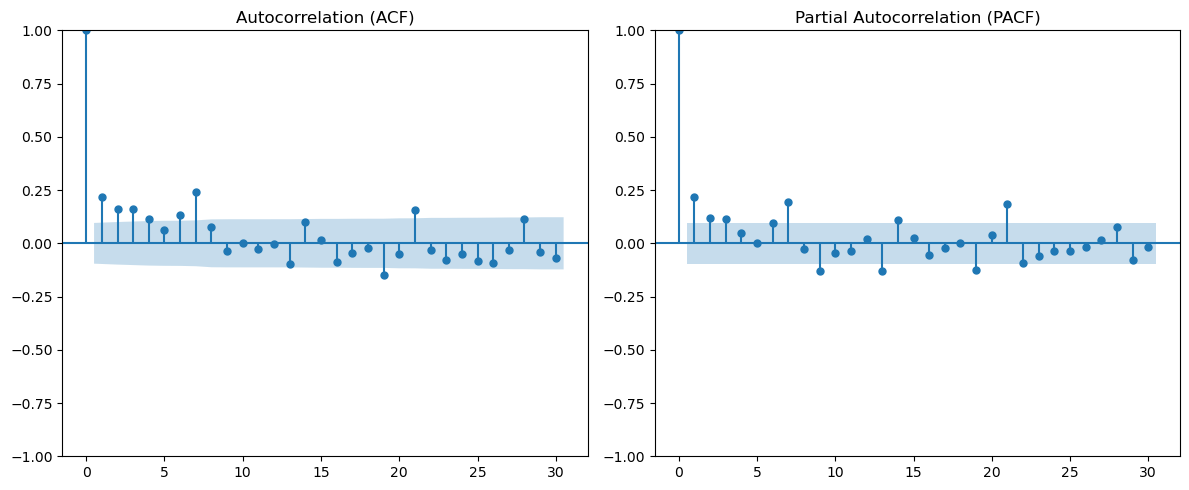

In [93]:

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# Confirm stationarity with ADF test
adf_result = adfuller(combined_df['Actual'])
print("ADF Test Results:")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

# Plot ACF and PACF to estimate p and q
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_acf(combined_df['Actual'], ax=plt.gca(), lags=30)
plt.title('Autocorrelation (ACF)')

plt.subplot(1, 2, 2)
plot_pacf(combined_df['Actual'], ax=plt.gca(), lags=30)
plt.title('Partial Autocorrelation (PACF)')

plt.tight_layout()
plt.show()


In [94]:

import statsmodels.api as sm

# Fit ARIMA(1, 0, 1)
model_101 = sm.tsa.ARIMA(combined_df['Actual'], order=(1, 0, 1))
results_101 = model_101.fit()

# Fit ARIMA(1, 0, 2)
model_102 = sm.tsa.ARIMA(combined_df['Actual'], order=(1, 0, 2))
results_102 = model_102.fit()

# Compare AIC values
print("Model Comparison:")
print(f"ARIMA(1,0,1) AIC: {results_101.aic:.2f}")
print(f"ARIMA(1,0,2) AIC: {results_102.aic:.2f}")


Model Comparison:
ARIMA(1,0,1) AIC: 7868.49
ARIMA(1,0,2) AIC: 7870.45


The Augmented Dickey-Fuller (ADF) test shows that the data is stationary, meaning Mr Langerman's steps pattern doesn’t drift over time and we don’t need to apply differencing. To estimate how past steps influence future ones, I used autocorrelation (ACF) and partial autocorrelation (PACF) plots. These revealed that recent steps have a strong influence, suggesting we should include one autoregressive term and one moving average term in our model. I tested two models; ARIMA(1,0,1) and ARIMA(1,0,2) and found that ARIMA(1,0,1) fits better (due to its lower AIC). While this step focused on estimating parameters, it supports our earlier decision to use SARIMA, which will also account for any seasonal walking patterns. As a reminder, SARIMA had a lower AIC (7364.96).

## Forecasting

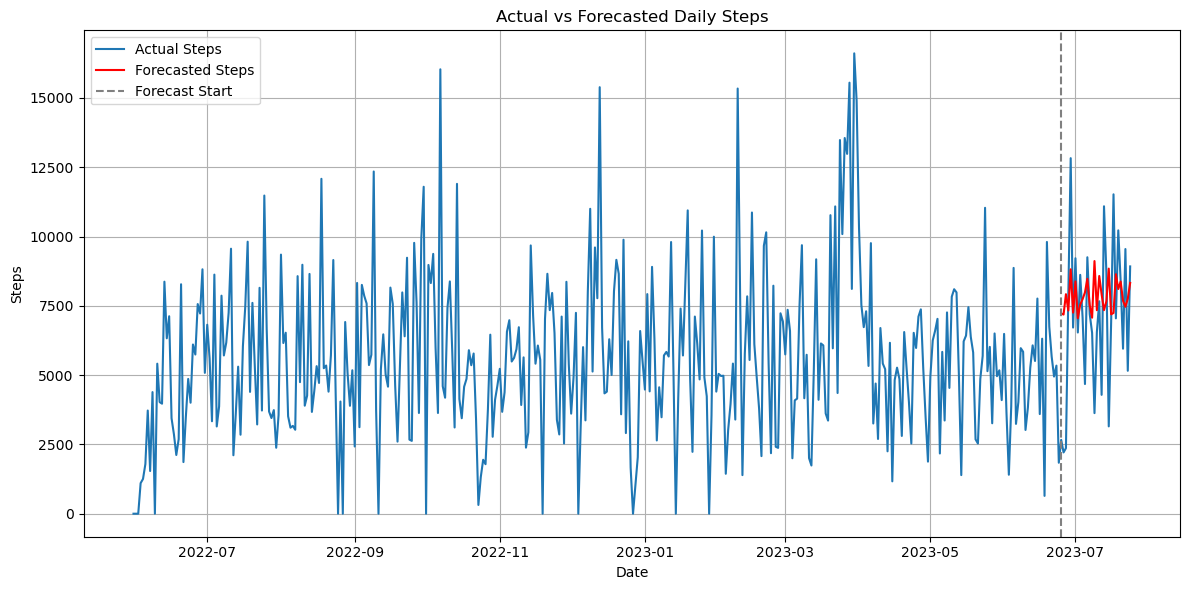

In [95]:

from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import pandas as pd

# Fit SARIMA model
model = SARIMAX(combined_df['Actual'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 30))
results = model.fit(disp=False)

# Forecast starting from 25 June 2023
start_date = pd.to_datetime("2023-06-25")
end_date = combined_df.index.max()
forecast_steps = (end_date - start_date).days + 1

forecast = results.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=start_date, periods=forecast_steps)
forecast_series = pd.Series(forecast.predicted_mean.values, index=forecast_index)

# Plot actual vs forecasted values
plt.figure(figsize=(12, 6))
plt.plot(combined_df['Actual'], label='Actual Steps')
plt.plot(forecast_series, label='Forecasted Steps', color='red')
plt.axvline(x=start_date, color='gray', linestyle='--', label='Forecast Start')
plt.title('Actual vs Forecasted Daily Steps')
plt.xlabel('Date')
plt.ylabel('Steps')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In the above graph, the blue line reflects the actual daily steps from mid-2022 to mid-2023. The red line is a reflection of the forecasted steps starting from 25 June 2023. The dashed gray line marks the point where the forecasting begins. The forecasted values (red line) appear to follow the general trend and variability of the actual data, which suggests the SARIMA model is capturing the seasonal and trend components well. The red line continues smoothly and realistically beyond the gray dashed line, which indicates a good model fit.

## Mean Squared Error (MSE), R-squared

In [96]:

from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Define forecast start date
start_date = pd.to_datetime("2023-06-25")

# Extract actual values from the same period as the forecast
actual_series = combined_df['Actual'].loc[start_date:]

# Align forecast and actual series
common_index = actual_series.index.intersection(forecast_series.index)
forecast_aligned = forecast_series.loc[common_index]
actual_aligned = actual_series.loc[common_index]

# Calculate accuracy metrics
mse = mean_squared_error(actual_aligned, forecast_aligned)
r2 = r2_score(actual_aligned, forecast_aligned)

print("Forecast Accuracy Metrics:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared: {r2:.4f}")


Forecast Accuracy Metrics:
Mean Squared Error (MSE): 7991528.01
R-squared: -0.1013


Even though SARIMA was statistically the best-fitting model (based on AIC/BIC), its forecast performance on the actual data from 25 June 2023 onward was not strong. The Mean Squared Error (MSE) of 7,991,528.01 is high, which indicates that the forecasted values differ significantly from the actual values on average. A negative R-squared (-0.1013) means the model performs worse than a horizontal line. This suggests the forecast didn’t capture the actual variation well during the forecast period (there could be various reasons for this, i.e., limited data for the forecast period or the model not capturing short-term fluctuations well). Because of this I will do further comparisons using other models too.

## Forecast Comparison Across Models

In [97]:

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Forecast start date
start_date = pd.to_datetime("2023-06-25")
actual_series = combined_df['Actual'].loc[start_date:]

# ARIMA model
arima_model = ARIMA(combined_df['Actual'], order=(1, 1, 1)).fit()
arima_forecast = arima_model.predict(start=start_date, end=actual_series.index[-1])

# Holt-Winters model
hw_model = ExponentialSmoothing(combined_df['Actual'], seasonal='add', seasonal_periods=30).fit()
hw_forecast = hw_model.predict(start=start_date, end=actual_series.index[-1])

# Align forecasts
common_index = actual_series.index.intersection(arima_forecast.index).intersection(hw_forecast.index).intersection(forecast_series.index)
actual_aligned = actual_series.loc[common_index]
arima_aligned = arima_forecast.loc[common_index]
hw_aligned = hw_forecast.loc[common_index]
sarima_aligned = forecast_series.loc[common_index]

# Calculate metrics
metrics = {
    "ARIMA MSE": mean_squared_error(actual_aligned, arima_aligned),
    "ARIMA R2": r2_score(actual_aligned, arima_aligned),
    "Holt-Winters MSE": mean_squared_error(actual_aligned, hw_aligned),
    "Holt-Winters R2": r2_score(actual_aligned, hw_aligned),
    "SARIMA MSE": mean_squared_error(actual_aligned, sarima_aligned),
    "SARIMA R2": r2_score(actual_aligned, sarima_aligned)
}

# Print results
print("Forecast Comparison Across Models:")
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")


Forecast Comparison Across Models:
ARIMA MSE: 7827108.3002
ARIMA R2: -0.0786
Holt-Winters MSE: 8530794.1420
Holt-Winters R2: -0.1756
SARIMA MSE: 7991528.0126
SARIMA R2: -0.1013


Three models( ARIMA, SARIMA, and Holt-Winters) were evaluated for forecasting accuracy using Mean Squared Error (MSE) and R-squared metrics. While all models showed limited predictive power, ARIMA slightly outperformed the others with the lowest MSE and highest R. This suggests that although SARIMA captured seasonality well, ARIMA may have better generalized the short-term dynamics of the data during the forecast period.

## Reflection 

In this project, I analyzed Mr. Langerman’s daily step data over a 15-month period to uncover trends, patterns, and forecast future activity. I began by preparing and cleaning the data, then confirmed that it was stationary using the Augmented Dickey-Fuller test. I also performed seasonal decomposition, which revealed clear recurring patterns; supporting the presence of seasonality in the data.

Although ARIMA is typically used for stationary data, I initially selected SARIMA because it can model both stationarity and seasonality, which were both present in this dataset. However, after comparinvarious g models using Mean Squared Error and R-squared metrics, I found that ARIMA slightly outperformed SARIMA and Holt-Winters in terms of forecast accuracySo even though it doesn't  handle seasonality directly, it was best for forecasting. . That said, evaluating the forecast was tricky due to the limited number of actual data points available after the forecast start date of 25 June 2023.

To guide my thinking and ensure that each step of the analysis was intentional, I chose to write brief descriptions after each graph. This helped me reflect on what the visualizations revealed and make informed decisions throughout the process. For example, Exploratory Data Analysis showed that Mr. Langerman’s average daily steps (5674) fell below his goal of 8000 steps, suggesting room for improvement in meeting his fitness targets. Visualizations such as rolling averages, monthly trends, and weekday vs weekend comparisons helped me better understand his activity patt;ns — particularly the fact that he tends to be more active during weekdays.

If I were to do this again, I would consider incorporating external fvents) and extending the forecast window to improve model performance and interpretation.